In [ ]:
##Most of the questions in this notebook come from (Hull, J. (2021). Options, Futures, and Other Derivatives. 
##(11th ed.). Pearson International. https://elibrary.pearson.de/book/99.150005/9781292410623)

In [1]:
#0.Warm-up: use Monte-carlo simulation (which simulates the risk-neutral world) to calculate pi.

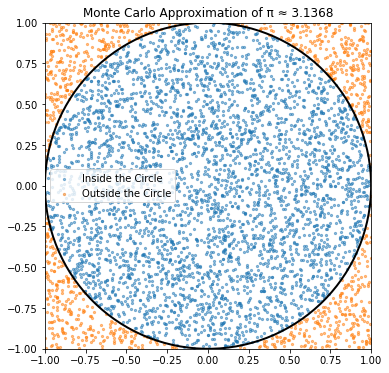

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Number of random points
N = 5000

# Set random x and y coordinates
x = np.random.uniform(-1, 1, N)
y = np.random.uniform(-1, 1, N)

# Check whether points are inside the circle
inside = x**2 + y**2 <= 1

# Count points inside the circle
count = np.sum(inside)

# Approximate pi
hat_pi = 4 * count / N

fig, ax = plt.subplots(figsize = (6,6))

# Points inside the circle
ax.scatter(x[inside], y[inside], s = 5, alpha = 0.5, label = 'Inside the Circle')

# Points outside the circle
ax.scatter(x[~inside], y[~inside], s = 5, alpha = 0.5, label = 'Outside the Circle')

# Plot the circle
circle = plt.Circle((0, 0), 1, fill = False, color = 'black', linewidth = 2)
ax.add_patch(circle)

# Plot the square boundaries
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)

# Make aspect ratio equal
ax.set_aspect('equal')

ax.set_title(f"Monte Carlo Approximation of π ≈ {hat_pi}")

ax.legend()

plt.show()

In [7]:
#1.Portfolio Optimisation. The covariance of two assets is defined by:

In [9]:
from IPython.display import display, Math

display(Math(
    r"\mathrm{Cov}(R_A, R_B) = "
    r"\frac{\sum_{i=1}^{n}(R_{Ai}-\overline{R_A})(R_{Bi}-\overline{R_B})}{n-1}."
))

<IPython.core.display.Math object>

In [ ]:
# Here R_Ai and R_Bi are the net returns of assets A and B in the ith interval, while R_A and R_B are the means of
# the returns of assets A and B, and n is the sample size or the number of intervals.

In [13]:
import numpy as np
from scipy.stats import norm

# Expected returns and covariance matrix of asset returns
R = np.array([0.14, 0.11, 0.20])
Sigma = np.array([
    [0.09, 0.07, 0.10],
    [0.08, 0.03, 0.06],
    [0.07, 0.05, 0.04]
])

# Portfolio weights
w = np.array([0.3, 0.5, 0.2])

# Expected portfolio return
mu_p = np.dot(w, R)

# Expected portfolio variance
sigma2_p = np.dot(w.T, np.dot(Sigma, w))

# Expected portfolio standard deviation (volatility)
sigma_p = np.sqrt(sigma2_p)

# Confidence level
alpha = 0.95

# Z-score for the left tail
z = norm.ppf(1 - alpha)

# Value-at-Risk
VaR = -z * sigma_p - mu_p

# Expected shortfall
ES = -mu_p + sigma_p * norm.pdf(z) / (1 - alpha)

print(f"Expected Portfolio Return: {mu_p:.2f}")
print(f"Expected Portfolio Volatility: {sigma_p:.2f}")
print(f"95% VaR: {VaR:.2f}")
print(f"Expected Shortfall: {ES:.2f}")

Expected Portfolio Return: 0.14
Expected Portfolio Volatility: 0.25
95% VaR: 0.27
Expected Shortfall: 0.37


In [1]:
#2.Binomial and Trinomial Trees

In [2]:
#2.1.A stock price is currently $50. Over each of the next two 3-month periods it is expected 
#to go up by 6% or down by 5%. The risk-free interest rate is 5% per annum with 
#continuous compounding. What is the value of a 6-month European call option with a 
#strike price of $51?

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import math

S0 = 50
K = 51
u = 1.06
d = 0.95
r = 0.05
dt = 0.25
N = 2

p = (math.exp(r * dt) - d) / (u - d)
disc = math.exp(-r * dt)

# stock-price binomial tree
stock = []
for i in range(N + 1): #range(3) means 0, 1, 2
    level = []
    for j in range(i + 1):
        S = S0 * (u ** j) * (d ** (i - j))
        level.append(S)
    stock.append(level)

# European call tree
call_tree = [None] * (N + 1)
call_tree[-1] = [max(S - K, 0) for S in stock[-1]]

for i in range(N - 1, -1, -1): #1,0
    call_tree[i] = []
    for j in range(i + 1):
        value = disc * (
            p * call_tree[i+1][j+1]
            + (1-p) * call_tree[i+1][j]
        )
        call_tree[i].append(value)

print ("The value of a 6-month European call option with a strike price of $51 is $",call_tree[0][0],".")#about $1.64

The value of a 6-month European call option with a strike price of $51 is $ 1.6350711385184167 .


In [11]:
#2.2.For the situation considered above, what is the value of a 6-month European 
#put option with a strike price of $51? Verify that the European call and European put 
#prices satisfy put–call parity. If the put option was American, would it ever be optimal 
#to exercise it early at any of the nodes on the tree?

In [15]:
#2.2.1
# European put tree
put_tree = [None] * (N + 1)
put_tree[-1] = [max(K - S, 0) for S in stock[-1]]

for i in range(N - 1, -1, -1):
    values = []
    for j in range(i + 1):
        value = disc * (p * put_tree[i+1][j+1] + (1-p) * put_tree[i+1][j])
        values.append(value)
    put_tree[i] = values

print ("The value of a 6-month European put option with a strike price of $51 is $",put_tree[0][0],".")#about $1.38

The value of a 6-month European put option with a strike price of $51 is $ 1.37587665196338 .


In [16]:
#2.2.2
# Check put-call parity
C = call_tree[0][0]
P = put_tree[0][0]
T = 0.5

LHS = C + K * math.exp(-r * T)
RHS = P + S0

print(LHS)
print(RHS)#The put-call parity holds.

51.37587665196338
51.37587665196338


In [19]:
#2.2.3
# American put tree
american_put_tree = [None] * (N + 1)
american_put_tree[-1] = [max(K - S, 0) for S in stock[-1]] #one choice equals European put

for i in range(N - 1, -1, -1):
    values = []
    for j in range(i + 1):
        continuation = disc * (
            p * american_put_tree[i+1][j+1]
            + (1-p) * american_put_tree[i+1][j]
        )
        exercise = max(K - stock[i][j], 0)
        values.append(max(continuation, exercise))
    american_put_tree[i] = values

print(american_put_tree)
print(put_tree)#It would be optimal to exercise it early at the down node after 3 months.

[[1.6456027941044589], [3.5, 0.27673731400258683], [5.875, 0.6500000000000057, 0]]
[[1.37587665196338], [2.8664678251879545, 0.27673731400258683], [5.875, 0.6500000000000057, 0]]


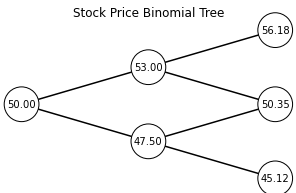

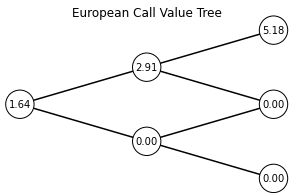

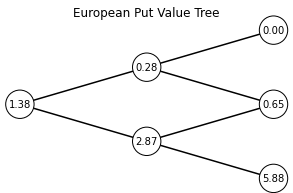

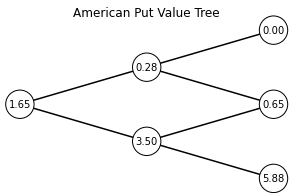

In [21]:
# Draw the trees
def draw_tree(tree, title):
    fig, ax = plt.subplots(figsize=(5, 3))

    for i, level in enumerate(tree):
        y_positions = np.linspace(-i, i, len(level))

        for j, value in enumerate(level):
            ax.text(i, y_positions[j], f"{value:.2f}",
                    ha="center", va="center",
                    bbox=dict(boxstyle="circle", facecolor="white"))

            if i < len(tree) - 1:
                next_y = np.linspace(-(i+1), i+1, len(tree[i+1]))
                ax.plot([i, i+1], [y_positions[j], next_y[j]], "k-")
                ax.plot([i, i+1], [y_positions[j], next_y[j+1]], "k-")

    ax.set_title(title)
    ax.axis("off")
    plt.show()

draw_tree(stock, "Stock Price Binomial Tree")
draw_tree(call_tree, "European Call Value Tree")
draw_tree(put_tree, "European Put Value Tree")
draw_tree(american_put_tree, "American Put Value Tree")

In [2]:
#2.3.Calculate the price of a 9-month American call option on corn futures when the current 
#futures price is 198 cents, the strike price is 200 cents, the risk-free interest rate is 8% per 
#annum, and the volatility is 30% per annum. Use a binomial tree with a time interval of 
#3 months.

In [3]:
import numpy as np
import math

F0 = 198       # current futures price
K = 200        # strike price
r = 0.08       # risk-free interest rate
sigma = 0.30   # volatility
T = 9/12
dt = 3/12

N = int(T / dt)

u = math.exp(sigma * math.sqrt(dt))
d = 1 / u

# risk-neutral probability
p = (1 - d)/(u - d)

discount = math.exp(-r * dt)

# Futures price tree
F_tree = []

for i in range(N + 1):
    level = []
    for j in range(i + 1):
        F = F0 * (u ** j) * (d ** (i - j))
        level.append(F)
    F_tree.append(level)
    
for level in F_tree:
    print(np.round(level, 4))

[198.]
[170.4202 230.0432]
[146.682 198.    267.272]
[126.2504 170.4202 230.0432 310.5258]


In [4]:
# American call option tree
call_tree = [[0 for j in range(i + 1)] for i in range(N + 1)]

# terminal payoff
for j in range(N + 1):
    call_tree[N][j] = max(F_tree[N][j] - K, 0)

# backward induction
for i in range(N - 1, -1, -1): #2,1,0
    for j in range(i + 1):
        continuation = discount * (
            p * call_tree[i + 1][j + 1]
            + (1 - p) * call_tree[i + 1][j]
        )
        exercise = max(F_tree[i][j] - K, 0)
        call_tree[i][j] = max(continuation, exercise)

for level in call_tree:
    print(np.round(level, 4))

print("American call price =", call_tree[0][0])#The 9-month American call price on corn futures is about $20.34.

[20.3371]
[ 6.1763 37.6777]
[ 0.     13.6219 67.272 ]
[  0.       0.      30.0432 110.5258]
American call price = 20.337084835543237


In [1]:
#2.4.The following questions are concerned with the alternative procedures for constructing trees in 2.3.

In [2]:
#2.4.1.Show that the binomial model in 2.3 is exactly consistent with the mean and
#variance of the change in the logarithm of the stock price in time ∆t.

In [17]:
import sympy as sp
from IPython.display import display

mu, sigma, dt = sp.symbols("mu sigma dt", positive=True)

u = sp.exp(sigma * sp.sqrt(dt))
d = sp.exp(-sigma * sp.sqrt(dt))
log_u = sp.log(u)
log_d = sp.log(d)

drift = (mu - sp.Rational(1, 2) * sigma**2) * dt
p = (drift - log_d) / (log_u - log_d)

mean = p * log_u + (1 - p) * log_d
variance = p * (log_u**2) + (1 - p) * (log_d**2) - mean**2

print("Mean of ln(S) change:")
display(sp.simplify(mean))#It verifies E[ΔlnS]=(μ−σ^2/2)Δt.
print("Variance of ln(S) change:")
display(sp.simplify(variance))#dt^2 -> 0, so it is σ^2 * dt, which verifies Var[ΔlnS]≈ σ^2Δt.

Mean of ln(S) change:


dt*(2*mu - sigma**2)/2

Variance of ln(S) change:


dt*(-4*dt*mu**2 + 4*dt*mu*sigma**2 - dt*sigma**4 + 4*sigma**2)/4

In [15]:
#2.4.2.Show that the trinomial model in 2.3 is consistent with the mean and 
#variance of the change in the logarithm of the stock price in time ∆t when terms of 
#order (∆t)^2 and higher are ignored.

In [27]:
import sympy as sp
from IPython.display import display

mu, sigma, dt = sp.symbols("mu sigma dt", positive=True)

u = sp.exp(sigma * sp.sqrt(3 * dt))
m = 1
d = sp.exp(-sigma * sp.sqrt(3 * dt))

p_u = sp.Rational(1, 6) + (mu - sigma**2 / 2) * sp.sqrt(dt) / (2 * sigma * sp.sqrt(3))
p_m = sp.Rational(2, 3)
p_d = sp.Rational(1, 6) - (mu - sigma**2 / 2) * sp.sqrt(dt) / (2 * sigma * sp.sqrt(3))

X_up = sp.log(u)
X_mid = sp.log(m)
X_down = sp.log(d)

mean_trinomial = sp.simplify(p_u * X_up + p_m * X_mid + p_d * X_down)
var_trinomial = sp.simplify(
    p_u * X_up**2 + p_m * X_mid**2 + p_d * X_down**2
    - mean_trinomial**2
)

print("Mean:")
display(mean_trinomial)#It verifies E[ΔlnS]=(μ−σ^2/2)Δt.

print("Variance:")
display(var_trinomial)#It verifies Var[ΔlnS]≈ σ^2Δt.

Mean:


dt*(2*mu - sigma**2)/2

Variance:


dt*(-4*dt*mu**2 + 4*dt*mu*sigma**2 - dt*sigma**4 + 4*sigma**2)/4

u = 1.2966806087260556
m = 1
d = 0.7711999341013249


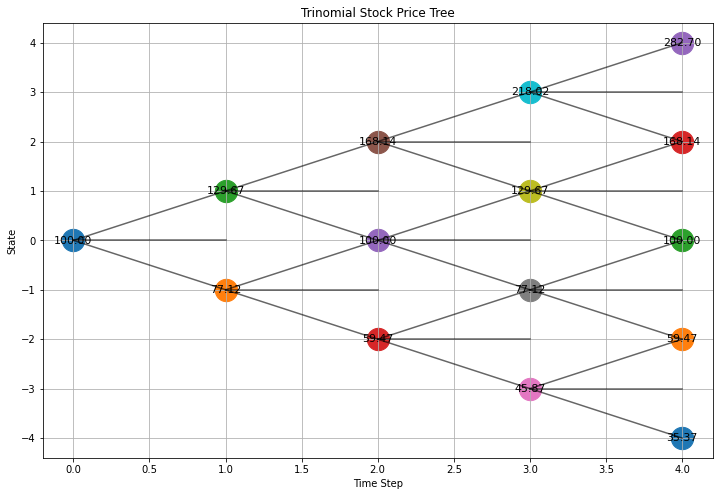

In [23]:
# Plot the trinomial tree
import numpy as np
import matplotlib.pyplot as plt
import math

# Parameters
S0 = 100
sigma = 0.3
T = 1
N = 4

dt = T / N

# Trinomial parameters
u = math.exp(sigma * math.sqrt(3 * dt))
m = 1
d = 1 / u

print("u =", u)
print("m =", m)
print("d =", d)

# Build trinomial tree
tree = []

for i in range(N + 1):

    level = []

    # j ranges from -i to +i
    for j in range(-i, i + 1):

        # Only reachable states
        if (i + j) % 2 == 0:

            S = S0 * (u ** max(j, 0)) * (d ** max(-j, 0))
            level.append((j, S))

    tree.append(level)

# Plot tree
plt.figure(figsize=(12, 8))

for i in range(len(tree)):

    for j, S in tree[i]:

        x = i
        y = j

        plt.scatter(x, y, s=500) #The node colours are defined randomly.

        plt.text(
            x,
            y,
            f"{S:.2f}",
            ha='center',
            va='center',
            color='black',
            fontsize=11
        )

        # Draw branches
        if i < N:

            for next_j in [j + 1, j, j - 1]:

                if abs(next_j) <= i + 1:

                    plt.plot(
                        [x, x + 1],
                        [y, next_j],
                        'k-',
                        alpha=0.6
                    )

plt.title("Trinomial Stock Price Tree")
plt.xlabel("Time Step")
plt.ylabel("State")

plt.grid(True)
plt.show()

In [ ]:
#2.4.3.Construct an alternative to the trinomial model in Section 21.4 so that the probabilities are 1/6, 2/3, and 1/6 on the upper, middle, and lower branches emanating 
#from each node. Assume that the branching is from S to Su, Sm, or Sd with m^2 = ud.
#Match the mean and variance of the change in the logarithm of the stock price exactly.

In [26]:
import sympy as sp
from IPython.display import display

mu, sigma, dt = sp.symbols("mu sigma dt", positive=True)

a = mu - sigma**2 / 2

log_m = a * dt
h = sigma * sp.sqrt(3 * dt)

log_u = log_m + h
log_d = log_m - h

u_alt = sp.exp(log_u)
m_alt = sp.exp(log_m)
d_alt = sp.exp(log_d)

print("u:")
display(u_alt)

print("m:")
display(m_alt)

print("d:")
display(d_alt)

print("Check m^2 = ud:")
display(sp.simplify(m_alt**2 - u_alt * d_alt))#match

u:


exp(sqrt(3)*sqrt(dt)*sigma + dt*(mu - sigma**2/2))

m:


exp(dt*(mu - sigma**2/2))

d:


exp(-sqrt(3)*sqrt(dt)*sigma + dt*(mu - sigma**2/2))

Check m^2 = ud:


0

In [1]:
#2.5.Estimate delta, gamma, and theta from a tree of an American call option on index futures.

In [5]:
import numpy as np

f00 = 19.16
f10 = 6.13
f11 = 33.64
f20 = 0.00
f21 = 12.90
f22 = 56.73
F0 = 300.00
u = 1.0905
d = 0.9170
dt = 0.0833
_2dt = 0.1667 #2*dt

h = 0.5 * (S0 * (u**2)- S0 * (d**2))

delta = (f11 - f10)/(F0 * u - F0 * d)
gamma = ((f22 - f21)/(F0 * (u**2) - F0) - (f21 - f20)/(F0 - F0 * (d**2))) / h
theta = (f21 - f00) / _2dt

print(f"Δ ≈ {delta:.2f}")#Each unit increase in the futures price increases the American call price by about 0.53.
print(f"Γ ≈ {gamma:.2f}")#Each unit increase in the futures price increases delta by about 0.01.
print(f"Θ ≈ {theta:.2f}")#All else being equal, the rate of change of the American call price is about -37.55 per year.

Δ ≈ 0.53
Γ ≈ 0.01
Θ ≈ -37.55
